# ABF to NWB to IPFX (Example)

This notebook demonstrates a complete workflow for this repository:
1. Define paths and import dependencies
2. Convert an ABF file to NWB
3. Load the NWB file with IPFX
4. Inspect basic sweep information

Each numbered workflow step is implemented as a single code cell.

## Step 1: Setup imports and file paths
This cell imports `convert_abf_to_nwb` and IPFX, then defines the input ABF and output NWB paths.

In [10]:
from pathlib import Path
import sys

from ipfx.dataset.create import create_ephys_data_set

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "example" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from abf2nwb import convert_abf_to_nwb

abf_path = PROJECT_ROOT / "data/2024_12_13_0020_for_nwb.abf"
output_path = PROJECT_ROOT / "data/example_output.nwb"

print(f"ABF input: {abf_path}")
print(f"NWB output: {output_path}")

ABF input: /Users/dmoracze/uv/abf2nwb/data/2024_12_13_0020_for_nwb.abf
NWB output: /Users/dmoracze/uv/abf2nwb/data/example_output.nwb


## Step 2: Convert ABF to NWB
This cell runs the conversion and writes the NWB file into the repository's `data/` directory.

In [11]:
convert_abf_to_nwb(
    abf_path=abf_path,
    output_path=output_path,
    response_channel=None,
    stimulus_description="C1LSCOARSE",
    session_description="Intracellular electrophysiology experiment.",
    timezone_name="America/New_York",
    experimenter=None,
    institution=None,
    lab=None,
)

print(f"Converted NWB written to: {output_path}")

Converted NWB written to: /Users/dmoracze/uv/abf2nwb/data/example_output.nwb


## Step 3: Verify ABF and NWB traces match
Set `sweep_selection` to choose sweeps and `view_mode` to `"abf"`, `"nwb"`, or `"both"` for voltage and stimulus plots.

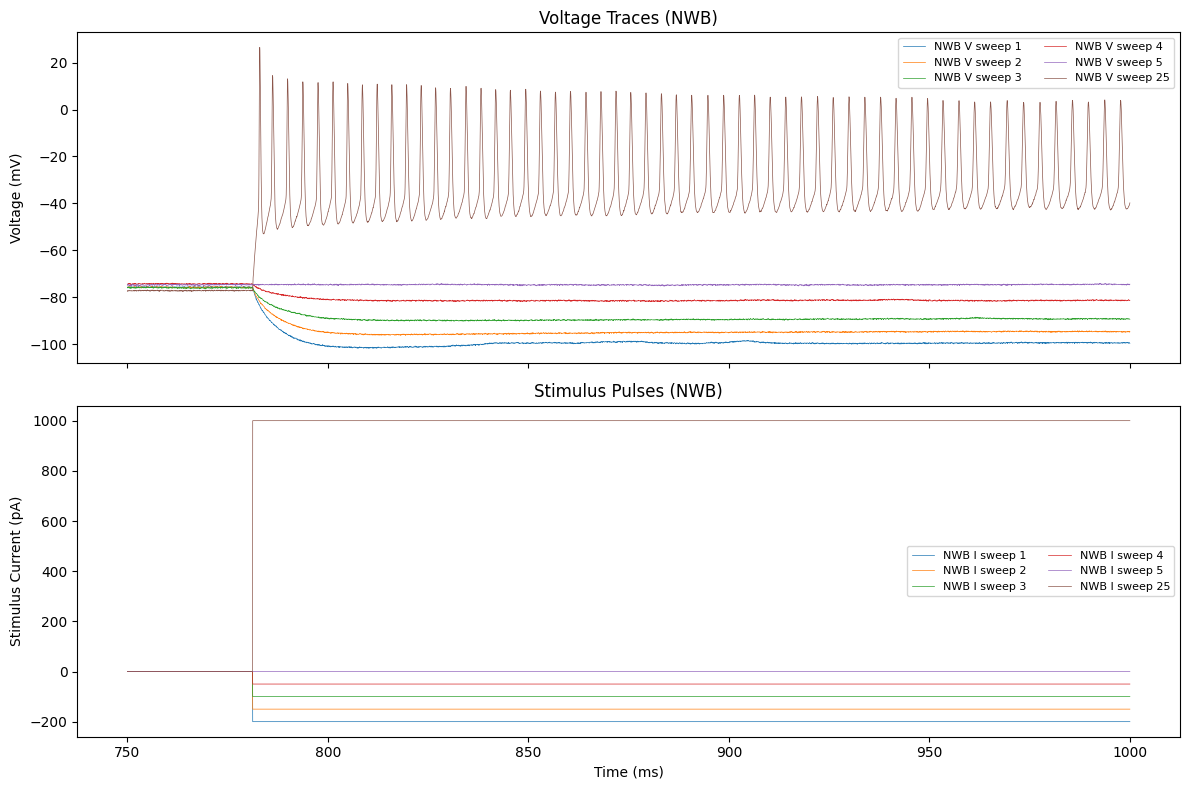

Sweep 1: max |dV| = 0 mV, max |dI| = 0 pA
Sweep 2: max |dV| = 0 mV, max |dI| = 0 pA
Sweep 3: max |dV| = 0 mV, max |dI| = 0 pA
Sweep 4: max |dV| = 0 mV, max |dI| = 0 pA
Sweep 5: max |dV| = 0 mV, max |dI| = 0 pA
Sweep 25: max |dV| = 0 mV, max |dI| = 1.13687e-13 pA
Overall max |dV|: 0 mV
Overall max |dI|: 1.13687e-13 pA


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pyabf
from pynwb import NWBHDF5IO

# User parameters
# sweep_selection examples: 1, range(1, 6), [1, 3, 5], (2, 8)
# view_mode options: "abf", "nwb", "both"
# time_range_ms examples: None, (100, 1200)
sweep_selection = [1,2,3,4,5,25]
view_mode = "nwb"
time_range_ms = (750,1000)

def normalize_sweep_selection(selection):
    if isinstance(selection, int):
        return [selection]
    if isinstance(selection, range):
        return list(selection)
    if isinstance(selection, tuple) and len(selection) == 2:
        start, stop = selection
        return list(range(int(start), int(stop) + 1))
    if isinstance(selection, list):
        return [int(x) for x in selection]
    raise ValueError("sweep_selection must be an int, range, list, or 2-item tuple.")

def normalize_time_range_ms(time_range):
    if time_range is None:
        return None
    if not (isinstance(time_range, tuple) and len(time_range) == 2):
        raise ValueError("time_range_ms must be None or a 2-item tuple: (start_ms, end_ms).")
    start_ms, end_ms = float(time_range[0]), float(time_range[1])
    if start_ms >= end_ms:
        raise ValueError("time_range_ms requires start_ms < end_ms.")
    return (start_ms / 1000.0, end_ms / 1000.0)

view_mode = str(view_mode).lower()
if view_mode not in {"abf", "nwb", "both"}:
    raise ValueError('view_mode must be one of: "abf", "nwb", "both"')

time_range_s = normalize_time_range_ms(time_range_ms)
sweep_numbers = normalize_sweep_selection(sweep_selection)

abf = pyabf.ABF(str(abf_path))
abf_current_to_pa = {"A": 1e12, "nA": 1e3, "pA": 1.0}.get(abf.sweepUnitsC, None)
if abf_current_to_pa is None:
    raise ValueError(f"Unsupported ABF stimulus unit: {abf.sweepUnitsC}")

with NWBHDF5IO(str(output_path), "r") as io:
    nwbfile = io.read()
    response_series_map = {
        int(series.name.split('-')[-1]): series
        for series in nwbfile.acquisition.values()
        if series.name.startswith("current_clamp-response-")
    }
    stimulus_series_map = {
        int(series.name.split('-')[-1]): series
        for series in nwbfile.stimulus.values()
        if series.name.startswith("stimulus-")
    }

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    max_abs_voltage_diffs = {}
    max_abs_stim_diffs = {}

    for sweep_number in sweep_numbers:
        if sweep_number < 1 or sweep_number > abf.sweepCount:
            raise ValueError(f"Sweep {sweep_number} is out of range for ABF with {abf.sweepCount} sweeps.")
        if sweep_number not in response_series_map:
            raise ValueError(f"Response sweep {sweep_number} not found in NWB acquisitions.")
        if sweep_number not in stimulus_series_map:
            raise ValueError(f"Stimulus sweep {sweep_number} not found in NWB stimulus series.")

        abf.setSweep(sweepNumber=sweep_number - 1, channel=0)
        abf_t = np.asarray(abf.sweepX, dtype=float)
        abf_v_mv = np.asarray(abf.sweepY, dtype=float)
        abf_i_pa = np.asarray(abf.sweepC, dtype=float) * abf_current_to_pa

        response_series = response_series_map[sweep_number]
        nwb_v_mv = np.asarray(response_series.data[:], dtype=float) * float(response_series.conversion) * 1e3
        nwb_t_v = float(response_series.starting_time) + np.arange(len(nwb_v_mv), dtype=float) / float(response_series.rate)

        stimulus_series = stimulus_series_map[sweep_number]
        nwb_i_pa = np.asarray(stimulus_series.data[:], dtype=float) * float(stimulus_series.conversion) * 1e12
        nwb_t_i = float(stimulus_series.starting_time) + np.arange(len(nwb_i_pa), dtype=float) / float(stimulus_series.rate)

        min_len_v = min(len(abf_t), len(nwb_t_v), len(abf_v_mv), len(nwb_v_mv))
        abf_t_v = abf_t[:min_len_v]
        abf_v_mv = abf_v_mv[:min_len_v]
        nwb_t_v = nwb_t_v[:min_len_v]
        nwb_v_mv = nwb_v_mv[:min_len_v]

        min_len_i = min(len(abf_t), len(nwb_t_i), len(abf_i_pa), len(nwb_i_pa))
        abf_t_i = abf_t[:min_len_i]
        abf_i_pa = abf_i_pa[:min_len_i]
        nwb_t_i = nwb_t_i[:min_len_i]
        nwb_i_pa = nwb_i_pa[:min_len_i]

        if time_range_s is not None:
            t_start, t_end = time_range_s
            mask_abf_v = (abf_t_v >= t_start) & (abf_t_v <= t_end)
            mask_nwb_v = (nwb_t_v >= t_start) & (nwb_t_v <= t_end)
            mask_abf_i = (abf_t_i >= t_start) & (abf_t_i <= t_end)
            mask_nwb_i = (nwb_t_i >= t_start) & (nwb_t_i <= t_end)

            if not np.any(mask_abf_v) or not np.any(mask_nwb_v) or not np.any(mask_abf_i) or not np.any(mask_nwb_i):
                raise ValueError("time_range_ms does not overlap available trace time for one or more selected sweeps.")

            abf_t_v, abf_v_mv = abf_t_v[mask_abf_v], abf_v_mv[mask_abf_v]
            nwb_t_v, nwb_v_mv = nwb_t_v[mask_nwb_v], nwb_v_mv[mask_nwb_v]
            abf_t_i, abf_i_pa = abf_t_i[mask_abf_i], abf_i_pa[mask_abf_i]
            nwb_t_i, nwb_i_pa = nwb_t_i[mask_nwb_i], nwb_i_pa[mask_nwb_i]

        min_len_v_cmp = min(len(abf_v_mv), len(nwb_v_mv))
        min_len_i_cmp = min(len(abf_i_pa), len(nwb_i_pa))
        max_abs_voltage_diffs[sweep_number] = float(np.max(np.abs(abf_v_mv[:min_len_v_cmp] - nwb_v_mv[:min_len_v_cmp])))
        max_abs_stim_diffs[sweep_number] = float(np.max(np.abs(abf_i_pa[:min_len_i_cmp] - nwb_i_pa[:min_len_i_cmp])))

        if view_mode in {"abf", "both"}:
            axes[0].plot(abf_t_v * 1000.0, abf_v_mv, label=f"ABF V sweep {sweep_number}", linewidth=2)
            axes[1].plot(abf_t_i * 1000.0, abf_i_pa, label=f"ABF I sweep {sweep_number}", linewidth=2)
        if view_mode in {"nwb", "both"}:
            axes[0].plot(nwb_t_v * 1000.0, nwb_v_mv, label=f"NWB V sweep {sweep_number}", linewidth=0.5, alpha=1)
            axes[1].plot(nwb_t_i * 1000.0, nwb_i_pa, label=f"NWB I sweep {sweep_number}", linewidth=0.5, alpha=1)

    axes[0].set_ylabel("Voltage (mV)")
    axes[0].set_title(f"Voltage Traces ({view_mode.upper()})")
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].set_xlabel("Time (ms)")
    axes[1].set_ylabel("Stimulus Current (pA)")
    axes[1].set_title(f"Stimulus Pulses ({view_mode.upper()})")
    axes[1].legend(ncol=2, fontsize=8)

    plt.tight_layout()
    plt.show()

for sweep_number in sweep_numbers:
    print(
        f"Sweep {sweep_number}: max |dV| = {max_abs_voltage_diffs[sweep_number]:.6g} mV, "
        f"max |dI| = {max_abs_stim_diffs[sweep_number]:.6g} pA"
    )
print(f"Overall max |dV|: {max(max_abs_voltage_diffs.values()):.6g} mV")
print(f"Overall max |dI|: {max(max_abs_stim_diffs.values()):.6g} pA")


## Step 4: Load the NWB file with IPFX
This cell opens the converted NWB file using IPFX's dataset loader.

In [13]:
data_set = create_ephys_data_set(str(output_path))
print("Loaded NWB into IPFX dataset object.")

Loaded NWB into IPFX dataset object.


## Step 5: Inspect sweep content
This cell prints basic metadata from the first sweep to verify successful import.

In [14]:
first_sweep = data_set._data.get_sweep_data(1)

print(f"Sweeps available: {len(data_set.sweep_table)}")
print(f"First sweep stimulus unit: {first_sweep['stimulus_unit']}")
print(f"First sweep sampling rate: {first_sweep['sampling_rate']}")
print(f"First sweep response samples: {len(first_sweep['response'])}")

Sweeps available: 25
First sweep stimulus unit: Amps
First sweep sampling rate: 20000.0
First sweep response samples: 40000


/Users/dmoracze/uv/abf2nwb/.venv/lib/python3.12/site-packages/ipfx/stimulus.py:155: UserWarning: Multiple stimuli match 'C1LSCOARSE', one expected
  warnings.warn("Multiple stimuli match '%s', one expected" % tag)


## Step 6: Run IPFX long square analysis
This cell selects `Long Square` sweeps, runs `LongSquareAnalysis`, and plots: response traces, F-I points, and spike counts.

/Users/dmoracze/uv/abf2nwb/.venv/lib/python3.12/site-packages/ipfx/stimulus.py:155: UserWarning: Multiple stimuli match 'C1LSCOARSE', one expected
  warnings.warn("Multiple stimuli match '%s', one expected" % tag)


Long square analysis did not produce a full feature set for this recording:
  Cannot find rheobase sweep in spiking sweeps with amplitudes:
Using sweep-level fallback for plotting.


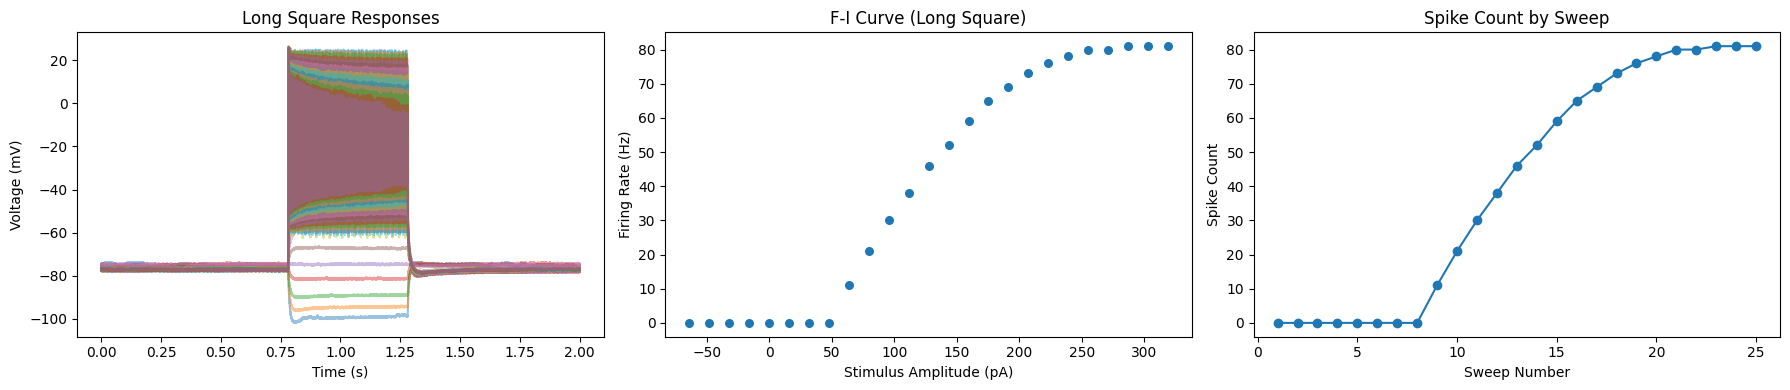

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor
from ipfx.stimulus_protocol_analysis import LongSquareAnalysis

long_square_table = data_set.filtered_sweep_table(
    clamp_mode=data_set.CURRENT_CLAMP,
    stimuli=["Long Square"],
)
long_square_sweep_numbers = long_square_table["sweep_number"].tolist()
long_square_sweeps = data_set.sweep_set(long_square_sweep_numbers)

spx = SpikeFeatureExtractor(start=0.1, end=1.1, filter=5.0)
sptx = SpikeTrainFeatureExtractor(start=0.1, end=1.1)
lsa = LongSquareAnalysis(
    spx=spx,
    sptx=sptx,
    subthresh_min_amp=-100.0,
    require_subthreshold=False,
    require_suprathreshold=False,
)

analysis_records = []
try:
    cell_features, sweep_features, cell_record, sweep_records = lsa.analyze(long_square_sweeps)
    analysis_records = sweep_records
    print(f"Long Square sweeps analyzed: {len(long_square_sweep_numbers)}")
    print(f"Cell feature keys (sample): {sorted(cell_features.keys())[:10]}")
    print(f"Sweep records: {len(sweep_records)}")
except ValueError as exc:
    print("Long square analysis did not produce a full feature set for this recording:")
    print(f"  {exc}")
    print("Using sweep-level fallback for plotting.")

if not analysis_records:
    for sweep in long_square_sweeps.sweeps:
        spikes = spx.process(sweep.t, sweep.v, sweep.i)
        duration = max(1e-9, (sptx.end - sptx.start))
        n_spikes = int(len(spikes))
        in_window = (sweep.t >= sptx.start) & (sweep.t <= sptx.end)
        stim_amp_pa = float(np.mean(sweep.i[in_window]))
        analysis_records.append(
            {
                "sweep_number": int(sweep.sweep_number),
                "n_spikes": n_spikes,
                "avg_rate": n_spikes / duration,
                "stim_amp": stim_amp_pa,
            }
        )

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for sweep in long_square_sweeps.sweeps:
    axes[0].plot(sweep.t, sweep.v, alpha=0.45)
axes[0].set_title("Long Square Responses")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Voltage (mV)")

fi_x = [float(record["stim_amp"]) for record in analysis_records if record.get("stim_amp") is not None]
fi_y = [float(record["avg_rate"]) for record in analysis_records if record.get("avg_rate") is not None]
if fi_x:
    axes[1].scatter(fi_x, fi_y, s=30)
axes[1].set_title("F-I Curve (Long Square)")
axes[1].set_xlabel("Stimulus Amplitude (pA)")
axes[1].set_ylabel("Firing Rate (Hz)")

sweep_idx = [int(record.get("sweep_number", i + 1)) for i, record in enumerate(analysis_records)]
spike_counts = [float(record["n_spikes"]) for record in analysis_records if record.get("n_spikes") is not None]
if spike_counts:
    axes[2].plot(sweep_idx[: len(spike_counts)], spike_counts, marker="o")
axes[2].set_title("Spike Count by Sweep")
axes[2].set_xlabel("Sweep Number")
axes[2].set_ylabel("Spike Count")

plt.tight_layout()
plt.show()